In [1]:
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
from sklearn.manifold import MDS
from scipy.interpolate import interp1d
import pickle

import helper

/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:106: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = windows.dot(grn)
/gpfs1/home/c/p/cpetak/Variability_of_Evolvability/helper.py:129: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float64, 2, 'C', False, aligned=True), Array(float64, 2, 'A', False, aligned=True))
  next_step = gene_vals.dot(internal_grn)


In [4]:
root="~/CA_GRN_results/detailed_save"

# Check evolved GRNs with unseen initial conditions

# Parameters
rule = 102
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1 #which gene was used to get fitness
seed_ints = [69904,149796]
try_seedints = [69904,149796,1024, 4147842,1238860,2481300]

#Targets
all_targs=[]
for s in try_seedints:
    random_grns=np.random.randn(5, grn_size+2, grn_size).astype(np.float64)
    targets, phenos, fitnesses = helper.get_pop_TPF(random_grns, len(random_grns), num_cells, grn_size, dev_steps, geneid, rule, s, s)
    all_targs.append(targets)

#Check GRNs from the last generation
varied_phenos, varied_fits, varied_genos = helper.try_grn(True, rule, seed_ints, try_seedints, grn_size, geneid, root, num_cells, dev_steps)
env1_phenos, env1_fits, env1_genos = helper.try_grn(False, rule, seed_ints[0], try_seedints, grn_size, geneid, root, num_cells, dev_steps)
env2_phenos, env2_fits, env2_genos = helper.try_grn(False, rule, seed_ints[1], try_seedints, grn_size, geneid, root, num_cells, dev_steps)

varied_df = pd.DataFrame(varied_fits.T, columns = try_seedints)
env1_df = pd.DataFrame(env1_fits.T, columns = try_seedints)
env2_df = pd.DataFrame(env2_fits.T, columns = try_seedints)
dfs=[varied_df, env1_df, env2_df]

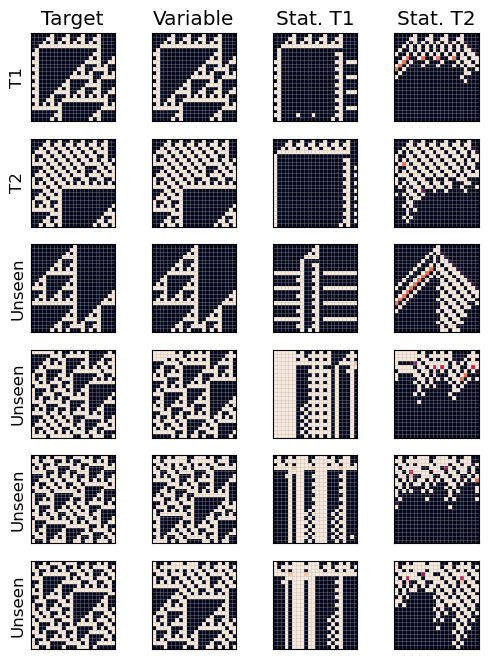

In [5]:
fig, axs = plt.subplots(6, 4, figsize=(6, 8), sharex=True, sharey=True)

plt.rcParams.update({"font.size": 12})

rep_id=2 #2 for 102, 12 for 70

for i in range(6):#looping through seeds
    helper.imshow_ca(all_targs[i], ax=axs[i,0])
    helper.imshow_ca(varied_phenos[i,rep_id,:,:], ax=axs[i,1])
    helper.imshow_ca(env1_phenos[i,rep_id,:,:], ax=axs[i,2])
    helper.imshow_ca(env2_phenos[i,rep_id,:,:], ax=axs[i,3])

axs[0,0].set_title('Target')
axs[0,1].set_title('Variable')
axs[0,2].set_title('Stat. T1')
axs[0,3].set_title('Stat. T2')

axs[0,0].set_ylabel("T1")
axs[1,0].set_ylabel("T2")
axs[2,0].set_ylabel("Unseen")
axs[3,0].set_ylabel("Unseen")
axs[4,0].set_ylabel("Unseen")
axs[5,0].set_ylabel("Unseen")

plt.savefig('figs/suppfig_3B.pdf', format='pdf', bbox_inches="tight")

In [ ]:
#Check GRN weight changes during evolution ------------------------------------------------

root="~/CA_GRN_results/detailed_save/"

# Load all GRNs, not just last generation

# Parameters
grn_size = 22
num_cells = 22
dev_steps = 22
geneid = 1 #which gene was used to get fitness
seed_ints = ["69904-149796","69904","149796"]
season_lens=[300,100_000,100_000]
folders = ["variable","static","static"]
rules = [f"{rule}-{rule}", rule, rule]
num_repeats = 15

allrules=[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]

vdata=[]
sdata=[]
s2data=[]
vdata_std=[]
sdata_std=[]
s2data_std=[]
for r in allrules:
    print(r)

    rules = [f"{r}-{r}", r, r]
    all_grns = []
    for g in range(len(season_lens)):
        grns=[np.loadtxt(os.path.expanduser(root+f"{folders[g]}/stats_{season_lens[g]}_{rules[g]}_{seed_ints[g]}_{i+1}_best_grn.txt")) for i in range(num_repeats)]
        grns = np.array(grns)
        num_grns = int(grns.shape[1]/(grn_size+2)/grn_size)
        grns = grns.reshape(num_repeats,num_grns,grn_size+2,grn_size) #repeats, gens, weights1, weights2
        tmp=np.reshape(grns, (num_repeats,num_grns,(grn_size+2)*grn_size))
        all_grns.append(tmp)
    all_grns=np.vstack(all_grns)

    # How much they travelled?
    #Variable experiments
    vari_grns = all_grns[:15,:,:]
    starts = vari_grns[:,0,:]
    ends = vari_grns[:,-1,:]
    diffsv = np.abs(ends - starts).mean(axis=1) #average across the genome
    vdata.append(diffsv)

    #Static 1 experiments
    s1_grns = all_grns[15:30,:,:]
    starts = s1_grns[:,0,:]
    ends = s1_grns[:,-1,:]
    diffss1 = np.abs(ends - starts).mean(axis=1)
    sdata.append(diffss1)

    #Static 1 experiments
    s2_grns = all_grns[30:,:,:]
    starts = s2_grns[:,0,:]
    ends = s2_grns[:,-1,:]
    diffss2 = np.abs(ends - starts).mean(axis=1)
    s2data.append(diffss2)

    # How different evolved GRNs are from each other?
    vari_stds = all_grns[:15, -1, :].std(axis = 0) #among 15 replicates std, should return 528 values
    s1_stds = all_grns[15:30, -1, :].std(axis = 0)
    s2_stds = all_grns[30:, -1, :].std(axis = 0)
    vdata_std.append(vari_stds) #averaged, only 1 values per rule
    sdata_std.append(s1_stds)
    s2data_std.append(s2_stds)


In [2]:
#Saving results
#data = {
    #'v': vdata,
    #'s': sdata,
    #'s2': s2data,
    #'vstd': vdata_std,
    #'sstd': sdata_std,
    #'s2std': s2data_std
#}

# Save to a file
#with open('grn_explore_measures.pkl', 'wb') as f:
    #pickle.dump(data, f)

with open(os.path.expanduser('~/CA_GRN_results/grn_explore_measures.pkl'), 'rb') as f:
    data = pickle.load(f)

vdata = data["v"]
sdata = data["s"]
s2data = data["s2"]
vdata_std = data["vstd"]
sdata_std = data["sstd"]
s2data_std = data["s2std"]

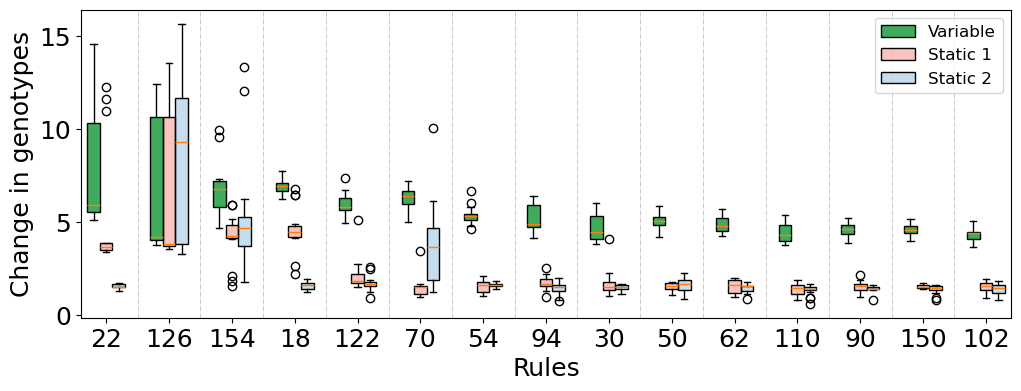

In [3]:
# Create the plot

allrules=[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
ixs = np.argsort(np.array(vdata).max(axis=1))[::-1]
vdata = np.array(vdata)
sdata = np.array(sdata)
s2data = np.array(s2data)

plt.figure(figsize=(12, 4))
scale = 2.5

positions1 = np.arange(1, len(vdata) + 1) * scale - 0.5  # Shift left
positions2 = np.arange(1, len(sdata) + 1) * scale  # Centered
positions3 = np.arange(1, len(s2data) + 1) * scale + 0.5  # Shift right

cmaps=["Greens", "Reds", "Blues"]
x=160

box1=plt.boxplot(vdata[ixs].T, positions=positions1, patch_artist=True)
for patch in box1['boxes']:
    color_map = plt.get_cmap(cmaps[0])
    patch.set_facecolor(color_map(x))
box2=plt.boxplot(sdata[ixs].T, positions=positions2, patch_artist=True)
for patch in box2['boxes']:
    color_map = plt.get_cmap(cmaps[1])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

box3=plt.boxplot(s2data[ixs].T, positions=positions3, patch_artist=True)
for patch in box3['boxes']:
    color_map = plt.get_cmap(cmaps[2])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

N = 14
for i in range(N):
    plt.axvline(positions3[i] + 0.75, linestyle="-.", alpha=0.3, c="black",lw=0.5)

plt.legend([box1["boxes"][0], box2["boxes"][0], box3["boxes"][0]], ["Variable", "Static 1", "Static 2"], loc="upper right",prop={'size': 12})
plt.xticks(ticks=np.arange(1, len(vdata) + 1)*scale, labels=allrules)
plt.ylabel("Change in genotypes", fontsize=18)
plt.xlabel("Rules", fontsize=18)
plt.tick_params(axis='both', which='major', labelsize=18)
#plt.show()
plt.savefig('figs/fig5C.pdf', format='pdf', bbox_inches="tight")

/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


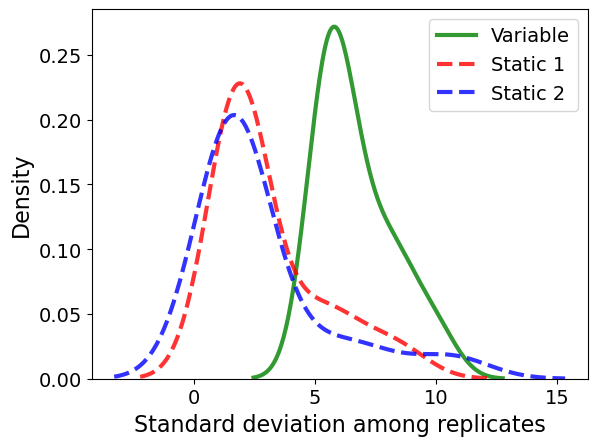

In [4]:
sns.kdeplot(np.array(vdata_std).mean(axis=1), color = "green", alpha = 0.8, label="Variable", lw=3)
sns.kdeplot(np.array(sdata_std).mean(axis=1), color = "red", alpha = 0.8, linestyle="--", label="Static 1", lw=3)
sns.kdeplot(np.array(s2data_std).mean(axis=1), color = "blue", alpha = 0.8, linestyle="--", label="Static 2", lw=3)
plt.legend(fontsize=14)
plt.xlabel("Standard deviation among replicates", fontsize=16)
plt.ylabel("Density", fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.savefig('figs/fig5B.pdf', format='pdf', bbox_inches="tight")

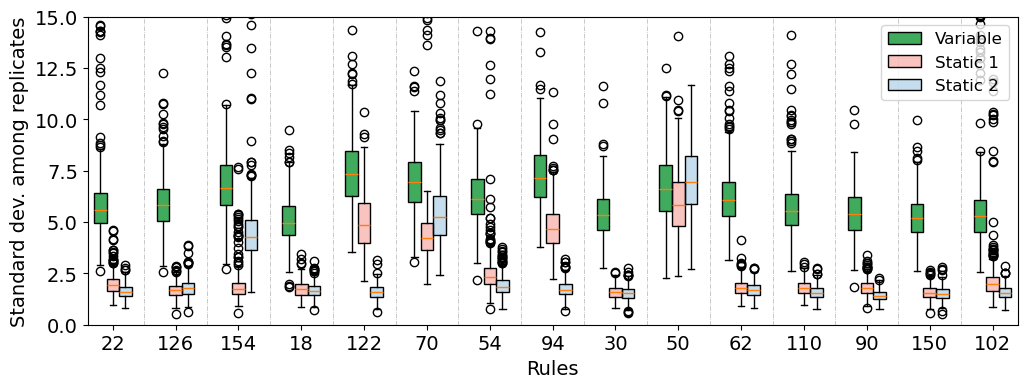

In [9]:
# Create the plot
plt.figure(figsize=(12, 4))
scale = 2.5

positions1 = np.arange(1, len(vdata_std) + 1) * scale - 0.5  # Shift left
positions2 = np.arange(1, len(sdata_std) + 1) * scale  # Centered
positions3 = np.arange(1, len(s2data_std) + 1) * scale + 0.5  # Shift right

cmaps=["Greens", "Reds", "Blues"]
x=160

box1=plt.boxplot(vdata_std, positions=positions1, patch_artist=True)
for patch in box1['boxes']:
    color_map = plt.get_cmap(cmaps[0])
    patch.set_facecolor(color_map(x))
box2=plt.boxplot(sdata_std, positions=positions2, patch_artist=True)
for patch in box2['boxes']:
    color_map = plt.get_cmap(cmaps[1])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

box3=plt.boxplot(s2data_std, positions=positions3, patch_artist=True)
for patch in box3['boxes']:
    color_map = plt.get_cmap(cmaps[2])
    rgba = color_map(x)
    patch.set_facecolor((rgba[0], rgba[1], rgba[2], 0.3))

N = 14
for i in range(N):
    plt.axvline(positions3[i] + 0.75, linestyle="-.", alpha=0.3, c="black",lw=0.5)

plt.legend([box1["boxes"][0], box2["boxes"][0], box3["boxes"][0]], ["Variable", "Static 1", "Static 2"], loc="upper right",prop={'size': 12})
plt.xticks(ticks=np.arange(1, len(vdata_std) + 1)*scale, labels=allrules)
plt.ylabel("Standard dev. among replicates", fontsize=14)
plt.xlabel("Rules", fontsize=14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.ylim(0,15)
plt.show()

In [15]:
#How do populations explore the genotype space? -------------------------------------------


#Difference between current gen and last gen in same environment previously

r=102
rules = [f"{r}-{r}", r, r]
seed_ints = ["69904-149796","69904","149796"]
season_lens=[300,100_000,100_000]
folders = ["variable","static","static"]
num_repeats = 15
grn_size = 22
root="~/CA_GRN_results/detailed_save/"

all_grns = []
for g in range(len(season_lens)):
    grns=[np.loadtxt(os.path.expanduser(root+f"{folders[g]}/stats_{season_lens[g]}_{rules[g]}_{seed_ints[g]}_{i+1}_best_grn.txt")) for i in range(num_repeats)]
    grns = np.array(grns)
    num_grns = int(grns.shape[1]/(grn_size+2)/grn_size)
    grns = grns.reshape(num_repeats,num_grns,grn_size+2,grn_size) #repeats, gens, weights1, weights2
    tmp=np.reshape(grns, (num_repeats,num_grns,(grn_size+2)*grn_size))
    all_grns.append(tmp)
all_grns=np.vstack(all_grns)

florp = np.arange(0,9899)
season_len = 300
n_seasons = int(np.floor(florp.shape[0]/season_len))
chunked_gens = np.array([florp[i*season_len:(i+1)*season_len] for i in range(n_seasons)])

assert chunked_gens.size == season_len * n_seasons #safety check

chunked_season1, chunked_season2 = chunked_gens[0::2], chunked_gens[1::2]
season_end_locs1 = np.array([299]).repeat(300*15).reshape(15,300)
season_locs1 = chunked_season1[1:,:] #seasons past the first
season_end_locs2 = np.array([599]).repeat(300*15).reshape(15,300)
season_locs2 = chunked_season2[1:,:] #seasons past the first

curr_grns = all_grns[:num_repeats,:,:]

season_end_grns = curr_grns[:,season_end_locs1,:]
season_grns = curr_grns[:,season_locs1,:]
result1 = np.abs(season_end_grns - season_grns) #season ends - next season generations
result1 = result1.reshape((num_repeats,15*300,528)) #flatten generations

season_end_grns = curr_grns[:,season_end_locs2,:]
season_grns = curr_grns[:,season_locs2,:]
result2 = np.abs(season_end_grns - season_grns) #season ends - next season generations
result2 = result2.reshape((num_repeats,15*300,528)) #flatten generations


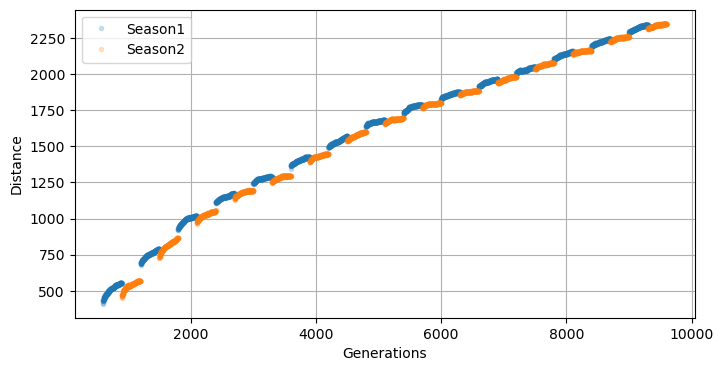

In [16]:
fig = plt.figure(figsize=(8,4))

x_vals = chunked_season1.flatten()[300:]
plt.plot(x_vals,result1.sum(axis=2).mean(axis=0),".",alpha=0.2, label="Season1")
x_vals = chunked_season2.flatten()[300:]
plt.plot(x_vals,result2.sum(axis=2).mean(axis=0),".",alpha=0.2, label="Season2")

plt.xlabel("Generations")
plt.ylabel("Distance")
plt.legend()
plt.grid()
plt.show()

In [17]:
#Difference between currect genotype and genotype at the end of last season, regardless of env

ends = florp[::300]
ends = ends -1
season_end_locs = ends[2:-1].repeat(300, axis = 0)#.reshape(15,300)
season_locs = florp[600:9600]

curr_grns = all_grns[:num_repeats,:,:]

season_end_grns = curr_grns[:,season_end_locs,:]
season_grns = curr_grns[:,season_locs,:]
result3 = np.abs(season_end_grns - season_grns) #season ends - next season generations

Text(0, 0.5, 'Distance')

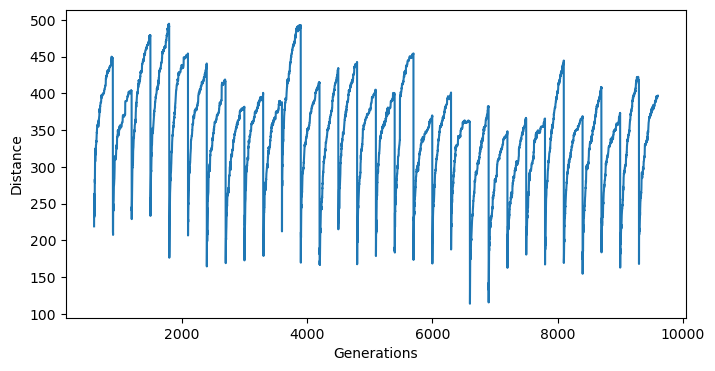

In [19]:
fig = plt.figure(figsize=(8,4))
x_vals = season_locs
plt.plot(x_vals,result3.sum(axis=2).mean(axis=0))
plt.xlabel("Generations")
plt.ylabel("Distance")

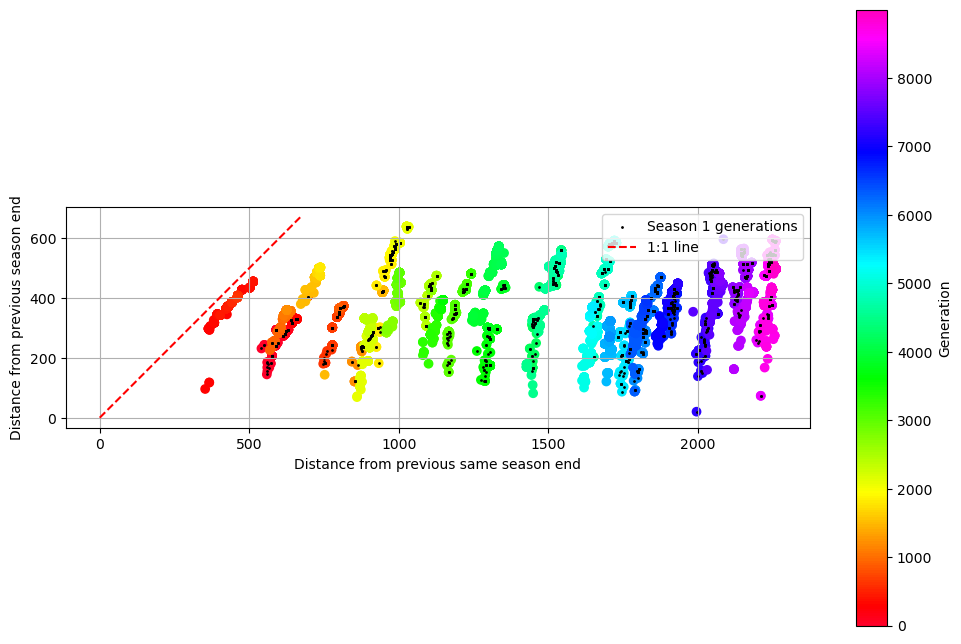

In [31]:
#GRNs change faster with respect to previous season than with respect to previous season that had the same environment

temp_chunks = chunked_season1[1:]-600

r = 3 #repeat number
arr1 = result1.sum(axis=2)[r].reshape((15,300))
arr2 = result2.sum(axis=2)[r].reshape((15,300))
interleaved = np.empty((arr1.shape[0] + arr2.shape[0], arr1.shape[1]), dtype=arr1.dtype)
# Fill the empty array by alternating rows from arr1 and arr2
interleaved[0::2] = arr1  # Place arr1 rows at even indices
interleaved[1::2] = arr2  # Place arr2 rows at odd indices

prev_change = result3.sum(axis=2)[r]

fig = plt.figure(figsize=(12,8))
colors = np.arange(len(prev_change))
plt.scatter(interleaved.flatten(),prev_change,c=colors, cmap='gist_rainbow')
plt.colorbar(label='Generation')
plt.scatter(interleaved.flatten()[temp_chunks.flatten()],prev_change[temp_chunks.flatten()],c="black", s=1, label = "Season 1 generations")

#Visual guide line
line_max = min(plt.xlim()[1], plt.ylim()[1])
plt.plot([0, line_max], [0, line_max], 'r--', label='1:1 line')

plt.grid()
plt.ylabel("Distance from previous season end")
plt.xlabel("Distance from previous same season end")
plt.gca().set_aspect('equal', adjustable='box')
plt.legend(loc="upper right")
plt.show()

Text(0.5, 0, 'Generations')

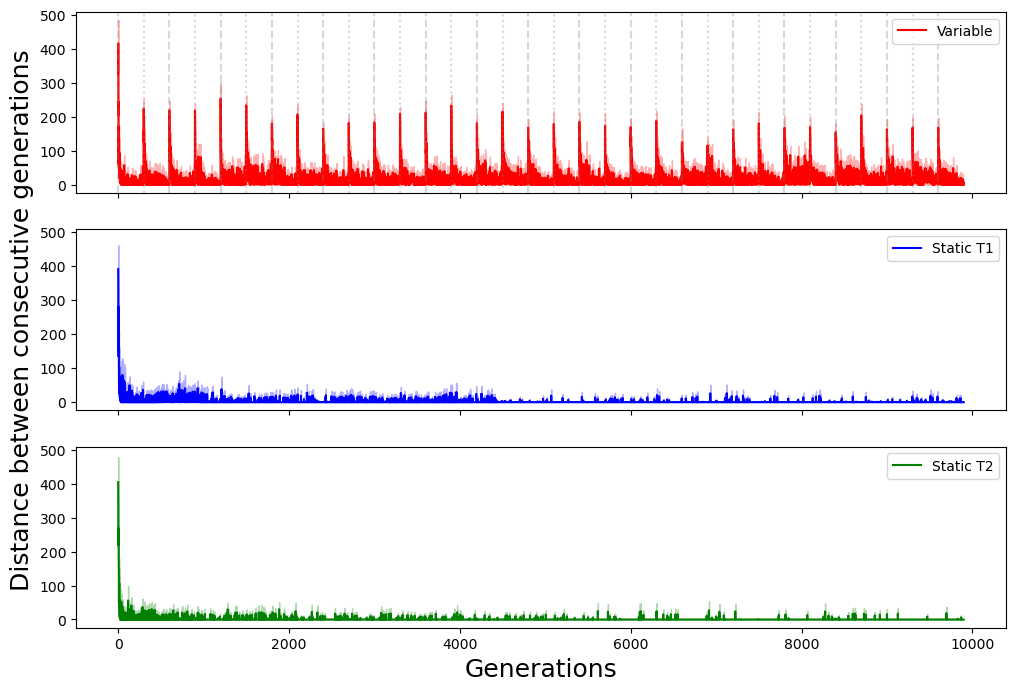

In [32]:
#Difference between consequtive generations

diff = np.abs(all_grns[:,1:] - all_grns[:,:-1])
diff=np.sum(diff,axis=2) #total difference across weights
diff = np.reshape(diff, (3,num_repeats,num_grns-1))

fig, ax = plt.subplots(figsize=(12,8), ncols=1, nrows=3, sharex=True, sharey=True)
cs=["red","blue","green"]
labels=["Variable", "Static T1", "Static T2", ]

for i in range(3):
    mean1 = np.mean(diff[i], axis=0) #average across replicated
    stderr1 = np.std(diff[i], axis=0) / np.sqrt(diff[i].shape[0])
    
    ax[i].plot(mean1,color=cs[i],label=labels[i])
    ax[i].fill_between(range(len(mean1)), mean1 - stderr1, mean1 + stderr1, color=cs[i], alpha=0.3)
    ax[i].legend()

for j in range(0, len(mean1), season_lens[0]):
    if j % (season_lens[0] * 2) == 0:
        ax[0].axvline(j, linestyle="--", color="gray", alpha=0.3)
    else:
        ax[0].axvline(j, linestyle=":", color="gray", alpha=0.3)
    
ax[1].set_ylabel("Distance between consecutive generations",fontsize=18)
plt.xlabel("Generations",fontsize=18)
#plt.savefig("figs/delta_gens.png")

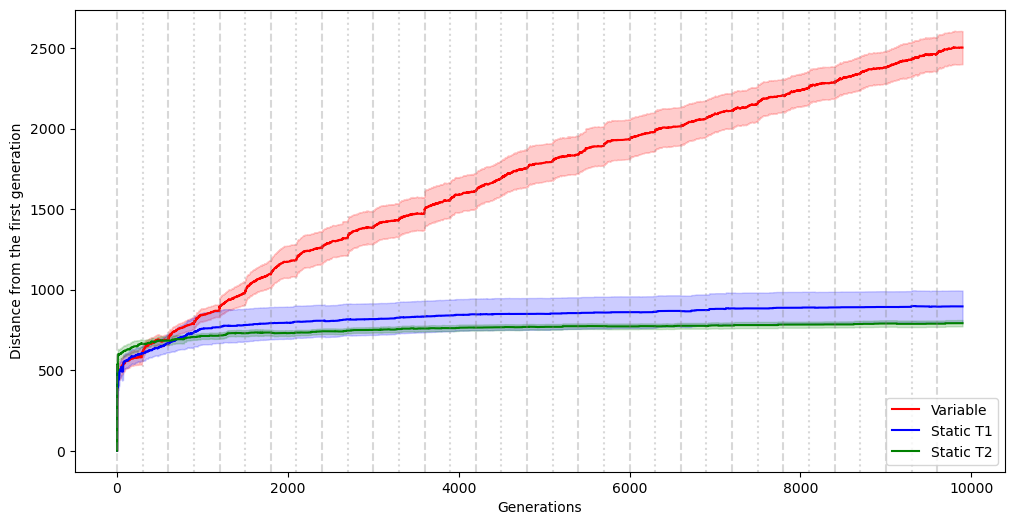

In [33]:
#Difference from the first generation

diff = np.abs(all_grns[:,0,np.newaxis] - all_grns[:,:-1])
diff=np.sum(diff,axis=2) #total difference across weights
diff = np.reshape(diff, (3,num_repeats,num_grns-1))

fig, ax = plt.subplots(figsize=(12,6))
for i in range(3):
    mean1 = np.mean(diff[i], axis=0)
    stderr1 = np.std(diff[i], axis=0) / np.sqrt(diff[i].shape[0])
    
    plt.plot(mean1,color=cs[i],label=labels[i])
    plt.fill_between(range(len(mean1)), mean1 - stderr1, mean1 + stderr1, color=cs[i], alpha=0.2)

for j in range(0, len(mean1), season_lens[0]):
    if j % (season_lens[0] * 2) == 0:
        ax.axvline(j, linestyle="--", color="gray", alpha=0.3)
    else:
        ax.axvline(j, linestyle=":", color="gray", alpha=0.3)

plt.ylabel("Distance from the first generation")
plt.xlabel("Generations")
plt.legend()
plt.show()
#plt.savefig("figs/delta_first.png")

In [7]:
#Selecting generations to track

num_generations=50
num_repeats=15
grn_size=22
check_freq = 150
test=np.array(list(range(9899)))
first_gen_list = test[check_freq-1::check_freq]
gens_to_get = first_gen_list.copy()


In [39]:
#Preparing data for Multidimensional scaling

r=18
rules = [f"{r}-{r}", r, r]
seed_ints = ["69904-149796","69904","149796"]
season_lens=[300,100_000,100_000]
folders = ["variable","static","static"]
num_repeats = 15
grn_size = 22
root="~/CA_GRN_results/detailed_save/"

all_grns = []
for g in range(len(season_lens)):
    grns=[np.loadtxt(os.path.expanduser(root+f"{folders[g]}/stats_{season_lens[g]}_{rules[g]}_{seed_ints[g]}_{i+1}_best_grn.txt")) for i in range(num_repeats)]
    grns = np.array(grns)
    num_grns = int(grns.shape[1]/(grn_size+2)/grn_size)
    grns = grns.reshape(num_repeats,num_grns,grn_size+2,grn_size) #repeats, gens, weights1, weights2
    tmp=np.reshape(grns, (num_repeats,num_grns,(grn_size+2)*grn_size))
    all_grns.append(tmp)
all_grns=np.vstack(all_grns)

temp_space=all_grns[:,np.array(gens_to_get),:]
space=np.reshape(temp_space, (temp_space.shape[0]*temp_space.shape[1],(grn_size*(grn_size+2)))) #put together repeats and generations
df = pd.DataFrame(space)


In [40]:
# Perform MDS transformation

mds = MDS(n_components=1, random_state=42)
mds_result = mds.fit_transform(df)
y=mds_result[:]
x=np.arange(temp_space.shape[1])

reps = [y[i*num_repeats*temp_space.shape[1]:(i+1)*num_repeats*temp_space.shape[1]].reshape(num_repeats,temp_space.shape[1]) for i in range(3)]

/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


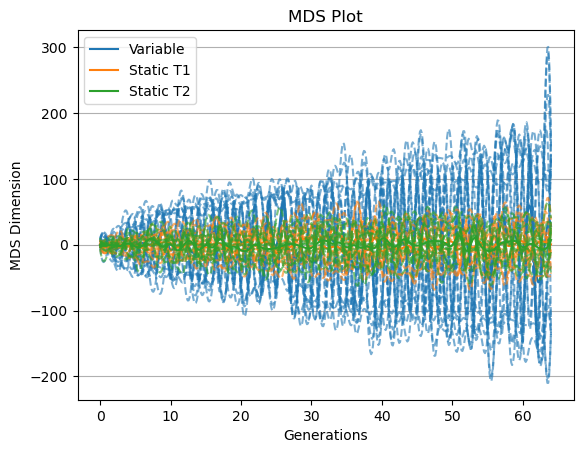

In [41]:
# Create a figure and axis
fig, ax = plt.subplots()

spline_res = 500

for i,rep in enumerate(reps):
    for run in rep:
        spline = interp1d(np.arange(run.shape[0]), run, kind='cubic')
        fine_xs = np.linspace(x.min(), x.max(), spline_res)
        plt.plot(fine_xs, spline(fine_xs), "--", c=f"C{i}",alpha=0.6)

    m_rep = np.mean(rep, axis=0)
    spline = interp1d(np.arange(m_rep.shape[0]), m_rep, kind='cubic')
    fine_xs = np.linspace(x.min(), x.max(), spline_res)
    plt.plot(fine_xs, spline(fine_xs), c=f"C{i}",label=labels[i])

plt.xlabel('Generations')
plt.ylabel('MDS Dimension')
plt.legend()
plt.title('MDS Plot')
plt.grid(axis="y")
plt.show()

In [ ]:
# MDS with two dimensions

df = pd.DataFrame(space)
mds = MDS(n_components=2, random_state=42)
mds_result = mds.fit_transform(df)
y1=mds_result[:,0]
y2=mds_result[:,1]
x=np.arange(temp_space.shape[1])

#y1,y2 = pickle.load(open("2d_18.p", "rb"))

/users/c/p/cpetak/miniconda3/envs/ca_grn/lib/python3.11/site-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.
  warnings.warn(


In [5]:
def flower_plot(rule):
    y1,y2 = pickle.load(open(os.path.expanduser(f"~/CA_GRN_results/anal_saved_results/2d_{rule}.p"), "rb"))
    fig, ax = plt.subplots(figsize=(8,8))

    s1=np.reshape(y1,(3,15,len(gens_to_get)))
    s2=np.reshape(y2,(3,15,len(gens_to_get)))

    cmaps=["Greens", "Reds", "Blues"]
    labels=["Variable","Static 1", "Static 2"]

    rep_ids = list(range(15))

    for i in range(3):
        for j in rep_ids:
            #if i== 2 and j==9:
                #print("nope")
                #pass
            #else:
            color_map = plt.get_cmap(cmaps[i])
            num_points = len(s2[i][j])
            for p in range(num_points):
                # Calculate color based on index
                color = color_map(p / (num_points - 1)+0.3)  # Normalize index to [0, 1]
                # Plot the point with adjusted color
                if p == int(num_points/2) and j==0:
                    plt.scatter(s1[i][j][p], s2[i][j][p], color=color,label=labels[i])# edgecolor='black')
                else:
                    plt.scatter(s1[i][j][p], s2[i][j][p], color=color)# edgecolor='black')

    plt.xlabel("MDS dimension 1", fontsize=22)
    plt.ylabel("MDS dimension 2", fontsize=22)
    plt.legend(loc="upper right", prop={'size': 18},handletextpad=0.1)
    plt.tick_params(axis='both', which='major', labelsize=18)
    #plt.show()
    plt.savefig('figs/fig5A.pdf', format='pdf', bbox_inches="tight")

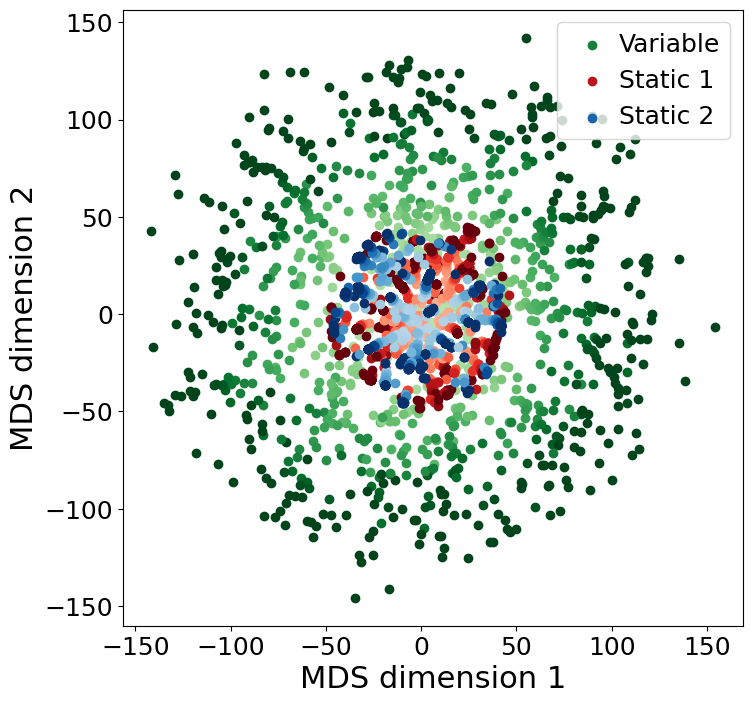

In [8]:
rules = [18] #[22, 126, 154, 18, 122, 70,54,94,30,50,62,110,90,150,102]
for rule in rules:
    flower_plot(rule)